Original order rows: 10009, Pre-snapshot rows: 8137
Missing Values Check:
loyalty_tier    1386
skin_type        401
dtype: int64


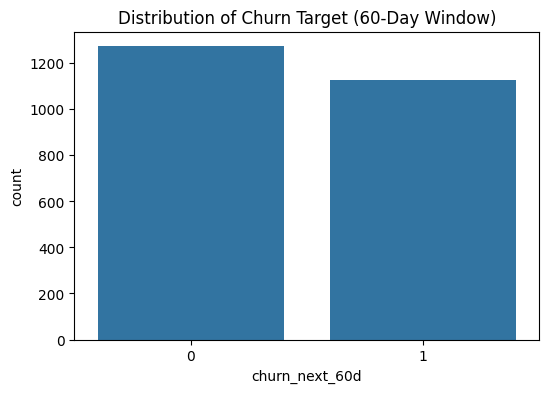

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


customers = pd.read_csv('customers.csv')
orders = pd.read_csv('orders.csv')
support_tickets = pd.read_csv('support_tickets.csv')
web_events = pd.read_csv('web_events_snapshot.csv')
churn_labels = pd.read_csv('churn_labels.csv')
intervention_history = pd.read_csv('intervention_history.csv')

# Leakage Prevention (Critical Step)
# Filter out post-snapshot orders (> 2025-09-30) to prevent target leakage
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders_pre_snapshot = orders[orders['order_date'] <= '2025-09-30'].copy()
print(f"Original order rows: {len(orders)}, Pre-snapshot rows: {len(orders_pre_snapshot)}")


df_base = customers.merge(web_events, on='customer_id', how='left') \
                   .merge(churn_labels, on='customer_id', how='left') \
                   .merge(intervention_history, on='customer_id', how='left')

order_stats = orders_pre_snapshot.groupby('customer_id').agg(
    total_spend=('gross_amount', 'sum'),
    total_orders=('order_id', 'nunique'),
    avg_discount=('discount_pct', 'mean')
).reset_index()

df_master = df_base.merge(order_stats, on='customer_id', how='left')

print("Missing Values Check:")
print(df_master.isnull().sum()[df_master.isnull().sum() > 0])


plt.figure(figsize=(6,4))
sns.countplot(data=df_master, x='churn_next_60d')
plt.title('Distribution of Churn Target (60-Day Window)')
plt.show()
